<a href="https://colab.research.google.com/github/sevval-345/SoftITo/blob/main/.polynomial_regression_gelismis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>




# 📈 Polinom Regresyon (Polynomial Regression)
### Hava Durumu Verisi Üzerinde Kapsamlı Analiz

---

> **Bu notebook**, WWII dönemine ait gerçek hava durumu istasyon verileri kullanılarak  
> polinom regresyonun adım adım, detaylı biçimde açıklandığı bir eğitim kaynağıdır.

| 📌 Konu | Polinom Regresyon |
|--------|-----------------|
| 🗂️ Veri Seti | Summary of Weather (119,040 gözlem) |
| 🎯 Hedef | MaxTemp → MeanTemp ve MinTemp Tahmini |
| 🛠️ Araçlar | scikit-learn, NumPy, Pandas, Matplotlib, Seaborn |

---


## 1. 📚 Polinom Regresyon Nedir?

Polinom regresyon, bağımsız değişken $x$ ile bağımlı değişken $y$ arasındaki  
**doğrusal olmayan (non-linear)** ilişkileri modellemek için kullanılan bir yöntemdir.

---

### 🔷 Doğrusal Regresyon vs Polinom Regresyon

**Basit Doğrusal Regresyon** (1. derece):
$$y = \beta_0 + \beta_1 x$$

**Polinom Regresyon** ($n$. derece):
$$y = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 + \cdots + \beta_n x^n$$

**⚠️ Önemli Fark:**  
Polinom regresyon, girdileri ($x^2, x^3, \dots$) dönüştürse de **katsayılar ($\beta$) hala doğrusaldır**.  
Bu yüzden model matematiksel açıdan **doğrusal bir modeldir** — sadece özellikler genişletilir.

---

### 🔷 Matris Gösterimi

Eğitim verisi için:

$$\mathbf{y} = \mathbf{X}_{poly} \cdot \boldsymbol{\beta}$$

Burada $\mathbf{X}_{poly}$:
$$\mathbf{X}_{poly} = \begin{bmatrix} 1 & x_1 & x_1^2 & \cdots & x_1^n \\ 1 & x_2 & x_2^2 & \cdots & x_2^n \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ 1 & x_m & x_m^2 & \cdots & x_m^n \end{bmatrix}$$

Katsayılar En Küçük Kareler yöntemiyle bulunur:
$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

---

### 🔷 Ne Zaman Kullanılır?

| Durum | Polinom Regresyon Uygun mu? |
|-------|---------------------------|
| Veri eğrisel bir trend izliyorsa | ✅ Evet |
| Doğrusal regresyon yetersiz kalıyorsa | ✅ Evet |
| Veri çok gürültülü ve karmaşıksa | ⚠️ Dikkatli kullan |
| Doğrusal ilişki yeterliyse | ❌ Gerek yok |

---

### 🔷 Bias-Variance Tradeoff (Önyargı-Varyans Dengesi)

```
Düşük Derece  ──→  Yüksek Bias   (Underfitting) ──→  Model çok basit
Yüksek Derece ──→  Yüksek Varyans (Overfitting)  ──→  Model çok karmaşık
```

En iyi model: **Test hatasını minimize eden dereceyi seçmek.**

## 2. 📦 Kütüphanelerin İçe Aktarılması

Aşağıdaki hücrede kullanacağımız tüm kütüphaneler yükleniyor:

| Kütüphane | Kullanım Amacı |
|-----------|---------------|
| `numpy` | Sayısal hesaplamalar, dizi işlemleri |
| `pandas` | Veri okuma, temizleme, manipülasyon |
| `matplotlib` | Temel grafik çizimi |
| `seaborn` | İstatistiksel görselleştirme |
| `PolynomialFeatures` | $x → [1, x, x^2, \ldots, x^n]$ dönüşümü |
| `LinearRegression` | OLS (En Küçük Kareler) ile katsayı tahmini |
| `make_pipeline` | Ön işleme + model adımlarını zincir haline getirir |
| `train_test_split` | Veriyi eğitim/test olarak böler |
| `r2_score`, `mean_squared_error` | Model performans metrikleri |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import FancyArrowPatch

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

# ── Grafik stili ayarları ──────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')
sns.set_palette('husl')

# ── Numpy yazdırma hassasiyeti ─────────────────────────────────────────────
np.set_printoptions(precision=4, suppress=True)

print('✅ Tüm kütüphaneler başarıyla yüklendi.')
print(f'   NumPy  : {np.__version__}')
print(f'   Pandas : {pd.__version__}')

✅ Tüm kütüphaneler başarıyla yüklendi.
   NumPy  : 2.0.2
   Pandas : 2.2.2


## 3. 🗂️ Veri Kümesinin Yüklenmesi ve İlk İnceleme

### Veri Seti Hakkında

- **Kaynak:** WWII Hava Durumu İstasyonu Ölçümleri  
- **Dönem:** 1942 - 1945 arası  
- **Kapsam:** Dünyanın farklı noktalarındaki hava istasyonları  
- **Boyut:** 119,040 satır × 31 sütun

**Kullanacağımız ana sütunlar:**

| Sütun | Açıklama | Birim |
|-------|----------|-------|
| `MaxTemp` | Günlük maksimum sıcaklık | °C |
| `MinTemp` | Günlük minimum sıcaklık | °C |
| `MeanTemp` | Günlük ortalama sıcaklık | °C |
| `Precip` | Yağış miktarı | mm |

In [7]:
# ── Veri setlerini oku ────────────────────────────────────────────────────
df_weather  = pd.read_csv('/content/Summary of Weather.csv', low_memory=False)
df_stations = pd.read_csv('/content/Weather Station Locations.csv')

# ── Temel bilgiler ────────────────────────────────────────────────────────
print('=' * 60)
print('📊 HAVA DURUMU VERİSİ (Summary of Weather)')
print('=' * 60)
print(f'  Satır sayısı  : {df_weather.shape[0]:,}')
print(f'  Sütun sayısı  : {df_weather.shape[1]}')
print(f'  Tarih aralığı : {df_weather["Date"].min()} → {df_weather["Date"].max()}')
print(f'  İstasyon sayısı: {df_weather["STA"].nunique()}')
print()
print('📍 İSTASYON KONUMLARI')
print(f'  {df_stations.shape[0]} istasyon, {df_stations.shape[1]} sütun')
print()

# ── İlk 5 satır ───────────────────────────────────────────────────────────
print('İlk 5 satır:')
df_weather[['STA', 'Date', 'MaxTemp', 'MinTemp', 'MeanTemp', 'Precip']].head()

📊 HAVA DURUMU VERİSİ (Summary of Weather)
  Satır sayısı  : 21,851
  Sütun sayısı  : 31
  Tarih aralığı : 1940-1-1 → 1945-9-9
  İstasyon sayısı: 21

📍 İSTASYON KONUMLARI
  161 istasyon, 8 sütun

İlk 5 satır:


,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip
0,10001,1942-7-1,25.555556,22.222222,23.888889,1.016
1,10001,1942-7-2,28.888889,21.666667,25.555556,0
2,10001,1942-7-3,26.111111,22.222222,24.444444,2.54
3,10001,1942-7-4,26.666667,22.222222,24.444444,2.54
4,10001,1942-7-5,26.666667,21.666667,24.444444,0


### 3.1 Sütun Veri Tipleri ve Eksik Değer Analizi

Hangi sütunlarda eksik veri var ve veri tipleri doğru mu?  
Bu adım **veri ön işleme** öncesi kritik bir kontrol adımıdır.

In [8]:
# ── Eksik değer analizi ───────────────────────────────────────────────────
null_counts = df_weather.isnull().sum()
null_pct    = (null_counts / len(df_weather) * 100).round(2)

null_df = pd.DataFrame({
    'Eksik Sayı': null_counts,
    'Eksik Yüzde (%)': null_pct,
    'Veri Tipi': df_weather.dtypes
}).sort_values('Eksik Sayı', ascending=False)

# Sadece eksik değer içeren sütunları göster
print('📋 Eksik Değer Raporu:')
print(null_df[null_df['Eksik Sayı'] > 0].to_string())
print()
print(f'⚠️  Toplam {(null_counts > 0).sum()} sütunda eksik veri mevcut.')

📋 Eksik Değer Raporu:
             Eksik Sayı  Eksik Yüzde (%) Veri Tipi
WindGustSpd       21851           100.00   float64
SPD               21851           100.00   float64
DR                21851           100.00   float64
RVG               21851           100.00   float64
FT                21851           100.00   float64
RHN               21851           100.00   float64
WTE               21851           100.00   float64
ITH               21851           100.00   float64
PGT               21851           100.00   float64
SD3               21851           100.00   float64
RHX               21851           100.00   float64
FTI               21851           100.00   float64
FB                21851           100.00   float64
SND               20640            94.46   float64
PoorWeather       13057            59.75    object
TSHDSBRSGF        13057            59.75    object
PRCP                320             1.46    object
MIN                 237             1.08   float64
MEA      

### 3.2 İstatistiksel Özet

`describe()` fonksiyonu; sayım, ortalama, standart sapma, min/max ve çeyreklik  
değerlerini verir. Aykırı değer (outlier) tespiti için ilk ipuçlarını burada alırız.

In [9]:
# ── İstatistiksel özet ────────────────────────────────────────────────────
stats = df_weather[['MaxTemp', 'MinTemp', 'MeanTemp', 'Precip']].describe().round(3)

# İçgörüler yazdır
print('📈 İstatistiksel Özet:')
print(stats)
print()
print('💡 İçgörüler:')
print(f'  • Ortalama MaxTemp : {stats.loc["mean", "MaxTemp"]:.1f}°C')
print(f'  • Ortalama MinTemp : {stats.loc["mean", "MinTemp"]:.1f}°C')
print(f'  • Ortalama MeanTemp: {stats.loc["mean", "MeanTemp"]:.1f}°C')
print(f'  • Sıcaklık aralığı : {stats.loc["min","MinTemp"]:.1f}°C → {stats.loc["max","MaxTemp"]:.1f}°C')
print(f'  • MaxTemp std      : {stats.loc["std","MaxTemp"]:.2f}°C  (yüksek çeşitlilik var)')

📈 İstatistiksel Özet:
         MaxTemp    MinTemp   MeanTemp
count  21851.000  21851.000  21851.000
mean      29.752     22.004     25.876
std        5.475      4.677      4.931
min      -17.778    -17.778    -17.778
25%       28.889     21.667     25.556
50%       30.556     22.778     26.667
75%       31.667     23.889     27.778
max       38.889     28.889     31.667

💡 İçgörüler:
  • Ortalama MaxTemp : 29.8°C
  • Ortalama MinTemp : 22.0°C
  • Ortalama MeanTemp: 25.9°C
  • Sıcaklık aralığı : -17.8°C → 38.9°C
  • MaxTemp std      : 5.47°C  (yüksek çeşitlilik var)


## 4. 🔧 Veri Ön İşleme

### Adımlar:
1. İlgili sütunları seç
2. Sayısal tipe dönüştür (bazı sütunlar `object` tipinde gelebilir)
3. Eksik değerleri temizle
4. Aykırı değerleri incele (IQR yöntemi)

### 🔷 IQR (Interquartile Range) ile Aykırı Değer Tespiti

$$IQR = Q_3 - Q_1$$
$$\text{Alt sınır} = Q_1 - 1.5 \times IQR \quad , \quad \text{Üst sınır} = Q_3 + 1.5 \times IQR$$

Bu sınırların dışındaki değerler **aykırı (outlier)** kabul edilir.



In [10]:
# ── Sütun seçimi ve tip dönüşümü ─────────────────────────────────────────
cols = ['MaxTemp', 'MinTemp', 'MeanTemp', 'Precip']
data = df_weather[cols].copy()

for col in cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

n_before = len(data)
data = data.dropna()
n_after  = len(data)

print(f'🧹 Temizleme Raporu:')
print(f'  Önceki satır sayısı : {n_before:,}')
print(f'  Sonraki satır sayısı: {n_after:,}')
print(f'  Silinen satır sayısı: {n_before - n_after:,} ({(n_before-n_after)/n_before*100:.2f}%)')
print()

# ── IQR ile aykırı değer analizi ──────────────────────────────────────────
print('🔍 IQR Aykırı Değer Analizi:')
for col in ['MaxTemp', 'MinTemp', 'MeanTemp']:
    Q1  = data[col].quantile(0.25)
    Q3  = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    print(f'  {col:10s} | IQR={IQR:.2f} | [{lower:.2f}, {upper:.2f}] | {len(outliers):,} aykırı değer ({len(outliers)/len(data)*100:.2f}%)')

print()
print('✅ Veri temizleme tamamlandı.')
data.head()

🧹 Temizleme Raporu:
  Önceki satır sayısı : 21,851
  Sonraki satır sayısı: 18,928
  Silinen satır sayısı: 2,923 (13.38%)

🔍 IQR Aykırı Değer Analizi:
  MaxTemp    | IQR=2.78 | [24.72, 35.83] | 814 aykırı değer (4.30%)
  MinTemp    | IQR=2.22 | [18.33, 27.22] | 1,300 aykırı değer (6.87%)
  MeanTemp   | IQR=2.22 | [22.22, 31.11] | 1,154 aykırı değer (6.10%)

✅ Veri temizleme tamamlandı.


,MaxTemp,MinTemp,MeanTemp,Precip
0,25.555556,22.222222,23.888889,1.016
1,28.888889,21.666667,25.555556,0.000
2,26.111111,22.222222,24.444444,2.540
3,26.666667,22.222222,24.444444,2.540
4,26.666667,21.666667,24.444444,0.000


## 5. 📊 Keşifsel Veri Analizi (EDA)

### 5.1 Değişken Dağılımları

Her sıcaklık değişkeninin nasıl dağıldığını inceleyelim.  
**Normal dağılım**, regresyon modellerinin varsayımlarından biridir.  
Histogram + KDE (Kernel Density Estimate) çifti bize bu bilgiyi verir.

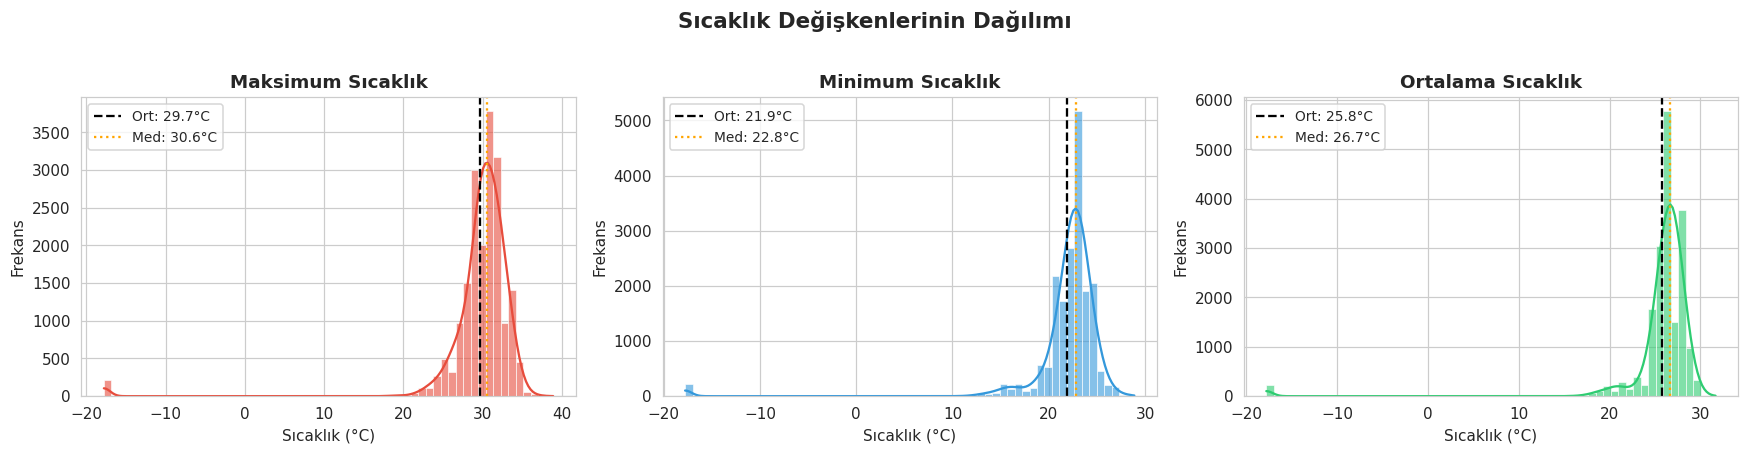

💡 Yorum:
  • Üç değişken de yaklaşık normal dağılıma sahip.
  • Ortalama ve medyan birbirine yakın → simetrik dağılım.
  • MaxTemp en yüksek ortalama, MinTemp en düşük ortalamaya sahip (beklenen).


In [11]:
# ── Dağılım grafikleri ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Sıcaklık Değişkenlerinin Dağılımı', fontsize=14, fontweight='bold', y=1.02)

vars_info = [
    ('MaxTemp',  '#e74c3c', 'Maksimum Sıcaklık'),
    ('MinTemp',  '#3498db', 'Minimum Sıcaklık'),
    ('MeanTemp', '#2ecc71', 'Ortalama Sıcaklık'),
]

for ax, (col, color, label) in zip(axes, vars_info):
    # Histogram + KDE
    sns.histplot(data[col], bins=60, kde=True, color=color, alpha=0.6, ax=ax)

    # Ortalama ve medyan çizgileri
    mean_val   = data[col].mean()
    median_val = data[col].median()
    ax.axvline(mean_val,   color='black',  linestyle='--', linewidth=1.5, label=f'Ort: {mean_val:.1f}°C')
    ax.axvline(median_val, color='orange', linestyle=':',  linewidth=1.5, label=f'Med: {median_val:.1f}°C')

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Sıcaklık (°C)')
    ax.set_ylabel('Frekans')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print('💡 Yorum:')
print('  • Üç değişken de yaklaşık normal dağılıma sahip.')
print('  • Ortalama ve medyan birbirine yakın → simetrik dağılım.')
print('  • MaxTemp en yüksek ortalama, MinTemp en düşük ortalamaya sahip (beklenen).')

### 5.2 Korelasyon Analizi & Scatter Plots

Polinom regresyon **bağımsız ve bağımlı değişken arasındaki** ilişkiyi modeller.  
Bu ilişkinin ne kadar güçlü olduğunu önce **Pearson korelasyon katsayısı** ile ölçelim:

$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i-\bar{x})^2 \cdot \sum(y_i-\bar{y})^2}}$$

- $r = 1$: Mükemmel pozitif doğrusal ilişki  
- $r = 0$: İlişki yok  
- $r = -1$: Mükemmel negatif doğrusal ilişki

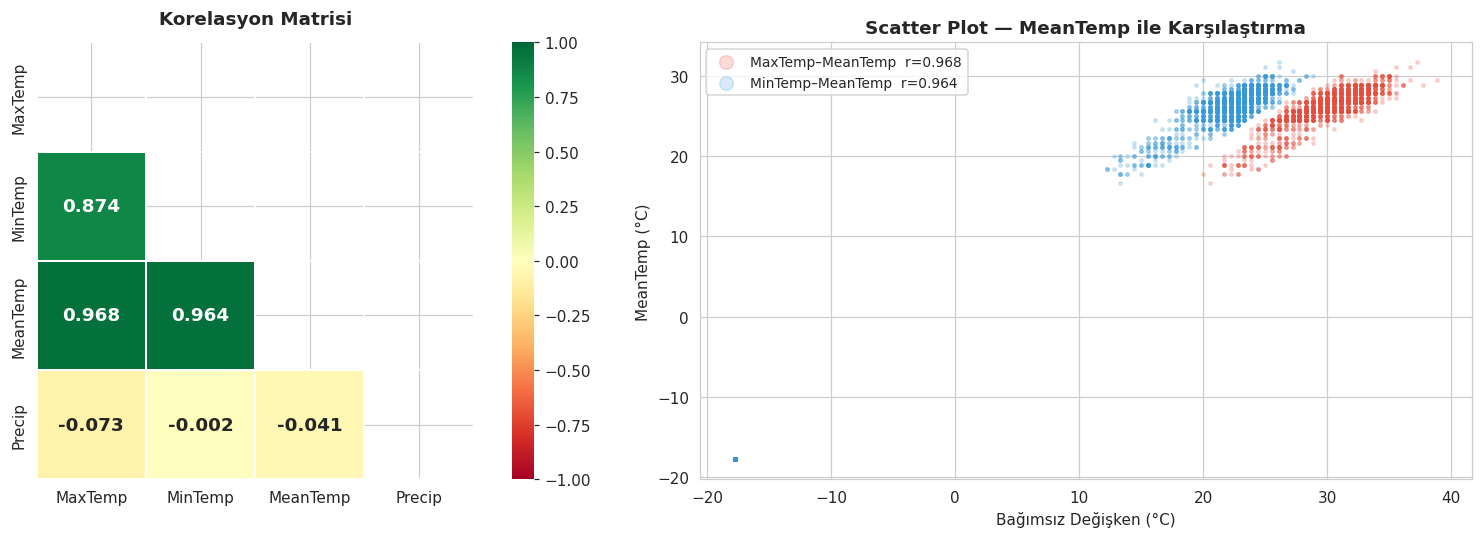

💡 Yorum:
  • MaxTemp–MeanTemp korelasyonu: r = 0.968  (çok güçlü pozitif ilişki)
  • MinTemp–MeanTemp korelasyonu: r = 0.964  (güçlü pozitif ilişki)
  • Bu yüksek korelasyon, doğrusal regresyonun da iyi çalışacağına işaret ediyor.
  • Polinom terimleri ek sapmaları yakalayabilir.


In [12]:
# ── Korelasyon ısı haritası ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Sol: Korelasyon matrisi
corr_matrix = data[['MaxTemp', 'MinTemp', 'MeanTemp', 'Precip']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Üst üçgeni gizle
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.3f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    square=True, linewidths=1, ax=axes[0],
    annot_kws={'size': 12, 'weight': 'bold'}
)
axes[0].set_title('Korelasyon Matrisi', fontweight='bold', pad=12)

# Sağ: Scatter plot matrix (pair plot özeti)
sample = data.sample(3000, random_state=42)  # 3000 örnek al (hız için)
axes[1].scatter(sample['MaxTemp'], sample['MeanTemp'], alpha=0.2, s=5,
                color='#e74c3c', label=f'MaxTemp–MeanTemp  r={corr_matrix.loc["MaxTemp","MeanTemp"]:.3f}')
axes[1].scatter(sample['MinTemp'], sample['MeanTemp'], alpha=0.2, s=5,
                color='#3498db', label=f'MinTemp–MeanTemp  r={corr_matrix.loc["MinTemp","MeanTemp"]:.3f}')
axes[1].set_xlabel('Bağımsız Değişken (°C)')
axes[1].set_ylabel('MeanTemp (°C)')
axes[1].set_title('Scatter Plot — MeanTemp ile Karşılaştırma', fontweight='bold')
axes[1].legend(fontsize=9, markerscale=4)

plt.tight_layout()
plt.show()

print('💡 Yorum:')
r_max  = corr_matrix.loc['MaxTemp','MeanTemp']
r_min  = corr_matrix.loc['MinTemp','MeanTemp']
print(f'  • MaxTemp–MeanTemp korelasyonu: r = {r_max:.3f}  (çok güçlü pozitif ilişki)')
print(f'  • MinTemp–MeanTemp korelasyonu: r = {r_min:.3f}  (güçlü pozitif ilişki)')
print(f'  • Bu yüksek korelasyon, doğrusal regresyonun da iyi çalışacağına işaret ediyor.')
print(f'  • Polinom terimleri ek sapmaları yakalayabilir.')

### 5.3 Box Plot — Aykırı Değer Görselleştirmesi

Box plot (kutu grafiği) 5 sayı özeti gösterir: Min, Q1, Medyan, Q3, Max.  
Bıyıkların ötesindeki noktalar **aykırı değer (outlier)** olarak işaretlenir.

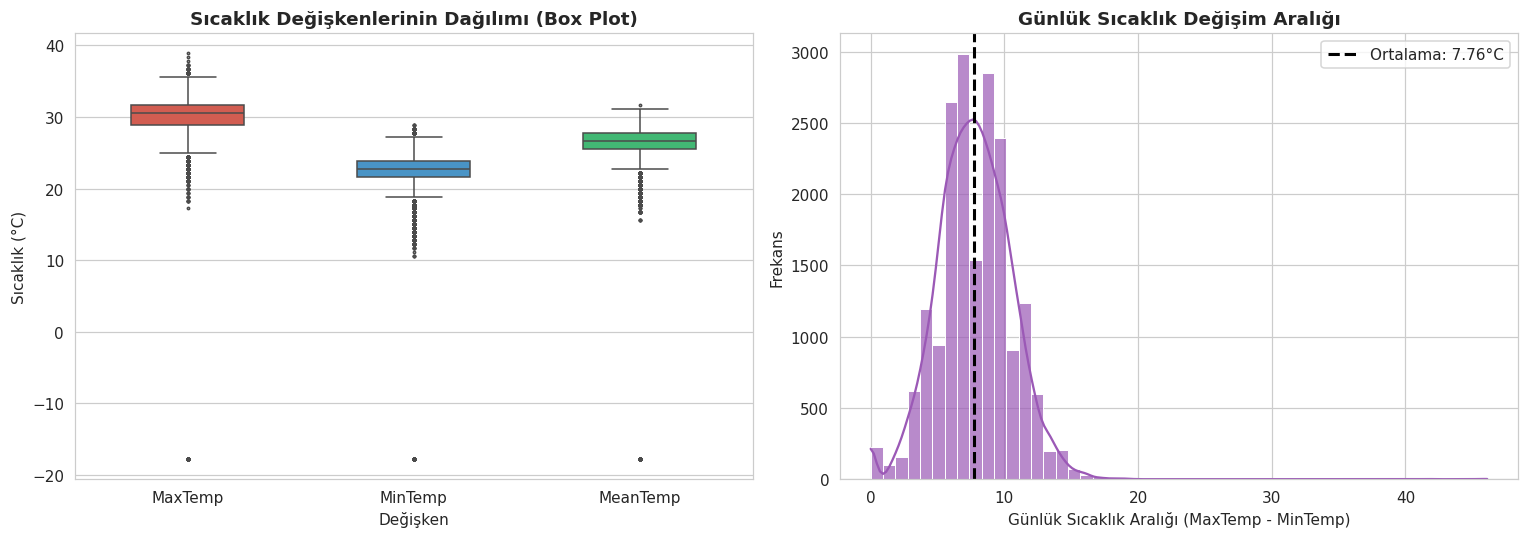

In [13]:
# ── Box plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol: Üç sıcaklık değişkeni birlikte
data_melted = data[['MaxTemp', 'MinTemp', 'MeanTemp']].melt(var_name='Değişken', value_name='Sıcaklık (°C)')
sns.boxplot(x='Değişken', y='Sıcaklık (°C)', data=data_melted,
            palette=['#e74c3c','#3498db','#2ecc71'],
            width=0.5, fliersize=1.5, ax=axes[0])
axes[0].set_title('Sıcaklık Değişkenlerinin Dağılımı (Box Plot)', fontweight='bold')

# Sağ: MaxTemp - MeanTemp farkı
data['TempRange'] = data['MaxTemp'] - data['MinTemp']
sns.histplot(data['TempRange'], bins=50, kde=True, color='#9b59b6', alpha=0.7, ax=axes[1])
axes[1].axvline(data['TempRange'].mean(), color='black', linestyle='--', linewidth=2,
                label=f'Ortalama: {data["TempRange"].mean():.2f}°C')
axes[1].set_xlabel('Günlük Sıcaklık Aralığı (MaxTemp - MinTemp)')
axes[1].set_ylabel('Frekans')
axes[1].set_title('Günlük Sıcaklık Değişim Aralığı', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. 🤖 Polinom Regresyon Modeli

### 6.1 Train-Test Ayrımı

Modelin **görülmemiş veri** üzerindeki başarısını ölçmek için veriyi  
%80 eğitim (train) ve %20 test olarak böleriz.

```
Tüm Veri (100%)
    ├── Eğitim Seti (80%) ──→ Modeli eğitmek için
    └── Test Seti   (20%) ──→ Performansı değerlendirmek için
```

**`random_state=42`**: Tekrarlanabilirlik için sabit rastgele tohum.  
**Neden %80-20?** Yeterince eğitim verisi + güvenilir test değerlendirmesi dengesi.

In [14]:
# ── Özellik ve hedef değişkeni belirle ───────────────────────────────────
# Bağımsız değişken (X): MaxTemp
# Bağımlı değişken (y) : MeanTemp

X = data[['MaxTemp']].values   # shape: (n, 1) — 2D olması gerekiyor
y = data['MeanTemp'].values    # shape: (n,)

# ── Train-Test split ──────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,    # %20 test
    random_state=42    # Tekrarlanabilirlik
)

print('📊 Veri Bölme Sonuçları:')
print(f'  Toplam veri : {len(X):,} örnek')
print(f'  Eğitim seti : {len(X_train):,} örnek ({len(X_train)/len(X)*100:.0f}%)')
print(f'  Test seti   : {len(X_test):,} örnek  ({len(X_test)/len(X)*100:.0f}%)')
print()
print(f'  X_train boyutu: {X_train.shape}')
print(f'  y_train boyutu: {y_train.shape}')
print()
print('💡 Neden 2D X?')
print('  scikit-learn modelleri X i (n_samples, n_features) formatında bekler.')
print('  data[["MaxTemp"]].values → (n,1)   ✅')
print('  data["MaxTemp"].values   → (n,)    ❌ (tek özellik için çalışır ama kötü alışkanlık)')

📊 Veri Bölme Sonuçları:
  Toplam veri : 18,928 örnek
  Eğitim seti : 15,142 örnek (80%)
  Test seti   : 3,786 örnek  (20%)

  X_train boyutu: (15142, 1)
  y_train boyutu: (15142,)

💡 Neden 2D X?
  scikit-learn modelleri X i (n_samples, n_features) formatında bekler.
  data[["MaxTemp"]].values → (n,1)   ✅
  data["MaxTemp"].values   → (n,)    ❌ (tek özellik için çalışır ama kötü alışkanlık)


### 6.2 Pipeline: PolynomialFeatures + LinearRegression

`make_pipeline` birden fazla adımı zincir haline getirir:

```
Girdi X                 PolynomialFeatures         LinearRegression
  [x]   ──────────→   [1, x, x², x³, ...]   ──→   ŷ = β₀ + β₁x + β₂x² + ...
```

**Avantajları:**
- Fit/transform/predict tek adımda yönetilir  
- Cross-validation ile bütün pipeline kolayca test edilir  
- Veri sızıntısı (data leakage) önlenir — dönüşüm sadece train verisi üzerinde öğrenilir

### 🔷 PolynomialFeatures ne yapar?

| Derece | Oluşturulan Özellikler |
|--------|----------------------|
| 1      | `[1, x]` |
| 2      | `[1, x, x²]` |
| 3      | `[1, x, x², x³]` |
| n      | `[1, x, x², ..., xⁿ]` |

In [ ]:
# ── Polinom dönüşümünü somut olarak görelim ───────────────────────────────
print('🔍 PolynomialFeatures Dönüşümü — Somut Örnek:')
print('   Girdi X = [[2], [3], [5]]')
print()

X_example = np.array([[2], [3], [5]])
for degree in [1, 2, 3]:
    pf = PolynomialFeatures(degree=degree, include_bias=True)
    X_transformed = pf.fit_transform(X_example)
    print(f'  Derece {degree}: {X_transformed.tolist()}')
    print(f'    Özellik isimleri: {pf.get_feature_names_out(["x"])}')
    print()

print('💡 "include_bias=True" → Sabit terim (1.0) sütunu eklenir.')
print('   Bu, LinearRegression intercept e karşılık gelir.')

### 6.3 Farklı Derecelerde Polinom Modelleri Eğitimi

Derece 1'den 10'a kadar modeller eğiteceğiz ve şu soruyu cevaplayacağız:  
**"Hangi derece en iyi genelleme yapar?"**

In [15]:
# ── Model eğitimi döngüsü ─────────────────────────────────────────────────
degrees = [1, 2, 3, 4, 5, 7, 10]
models  = {}
results = []

for degree in degrees:
    # Pipeline oluştur: PolynomialFeatures → LinearRegression
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=True),
        LinearRegression()
    )

    # Modeli SADECE eğitim verisiyle eğit
    model.fit(X_train, y_train)
    models[degree] = model

    # Tahminler
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    # Metrikler
    train_r2   = r2_score(y_train, y_train_pred)
    test_r2    = r2_score(y_test,  y_test_pred)
    train_mse  = mean_squared_error(y_train, y_train_pred)
    test_mse   = mean_squared_error(y_test,  y_test_pred)
    train_rmse = np.sqrt(train_mse)
    test_rmse  = np.sqrt(test_mse)

    results.append({
        'Derece'    : degree,
        'Train R²'  : round(train_r2,   4),
        'Test R²'   : round(test_r2,    4),
        'Δ R²'      : round(train_r2 - test_r2, 4),   # Overfitting göstergesi
        'Train RMSE': round(train_rmse, 4),
        'Test RMSE' : round(test_rmse,  4),
        'Train MSE' : round(train_mse,  4),
        'Test MSE'  : round(test_mse,   4),
    })

    # Kısa rapor
    flag = '⚠️ Overfitting riski!' if (train_r2 - test_r2) > 0.01 else '✅'
    print(f'Derece {degree:2d} | Train R²={train_r2:.4f} | Test R²={test_r2:.4f} | ΔR²={train_r2-test_r2:.4f} {flag}')

results_df = pd.DataFrame(results)
print()
print('─' * 65)
print('📋 Tam Sonuç Tablosu:')
print(results_df.to_string(index=False))

Derece  1 | Train R²=0.9330 | Test R²=0.9519 | ΔR²=-0.0188 ✅
Derece  2 | Train R²=0.9464 | Test R²=0.9650 | ΔR²=-0.0187 ✅
Derece  3 | Train R²=0.9505 | Test R²=0.9685 | ΔR²=-0.0179 ✅
Derece  4 | Train R²=0.9507 | Test R²=0.9688 | ΔR²=-0.0181 ✅
Derece  5 | Train R²=0.9514 | Test R²=0.9691 | ΔR²=-0.0176 ✅
Derece  7 | Train R²=0.9517 | Test R²=0.9696 | ΔR²=-0.0179 ✅
Derece 10 | Train R²=0.9517 | Test R²=0.9693 | ΔR²=-0.0176 ✅

─────────────────────────────────────────────────────────────────
📋 Tam Sonuç Tablosu:
 Derece  Train R²  Test R²    Δ R²  Train RMSE  Test RMSE  Train MSE  Test MSE
      1    0.9330   0.9519 -0.0188      1.3111     1.1794     1.7189    1.3911
      2    0.9464   0.9650 -0.0187      1.1734     1.0052     1.3768    1.0105
      3    0.9505   0.9685 -0.0179      1.1267     0.9546     1.2695    0.9113
      4    0.9507   0.9688 -0.0181      1.1247     0.9494     1.2649    0.9014
      5    0.9514   0.9691 -0.0176      1.1164     0.9451     1.2465    0.8933
      7    

### 6.4 Regresyon Eğrilerinin Görselleştirilmesi

Farklı derecelerin veriyi nasıl fit ettiğini görelim.  
Çok düşük dereceli modeller **underfitting**, çok yüksek dereceli modeller **overfitting** gösterir.

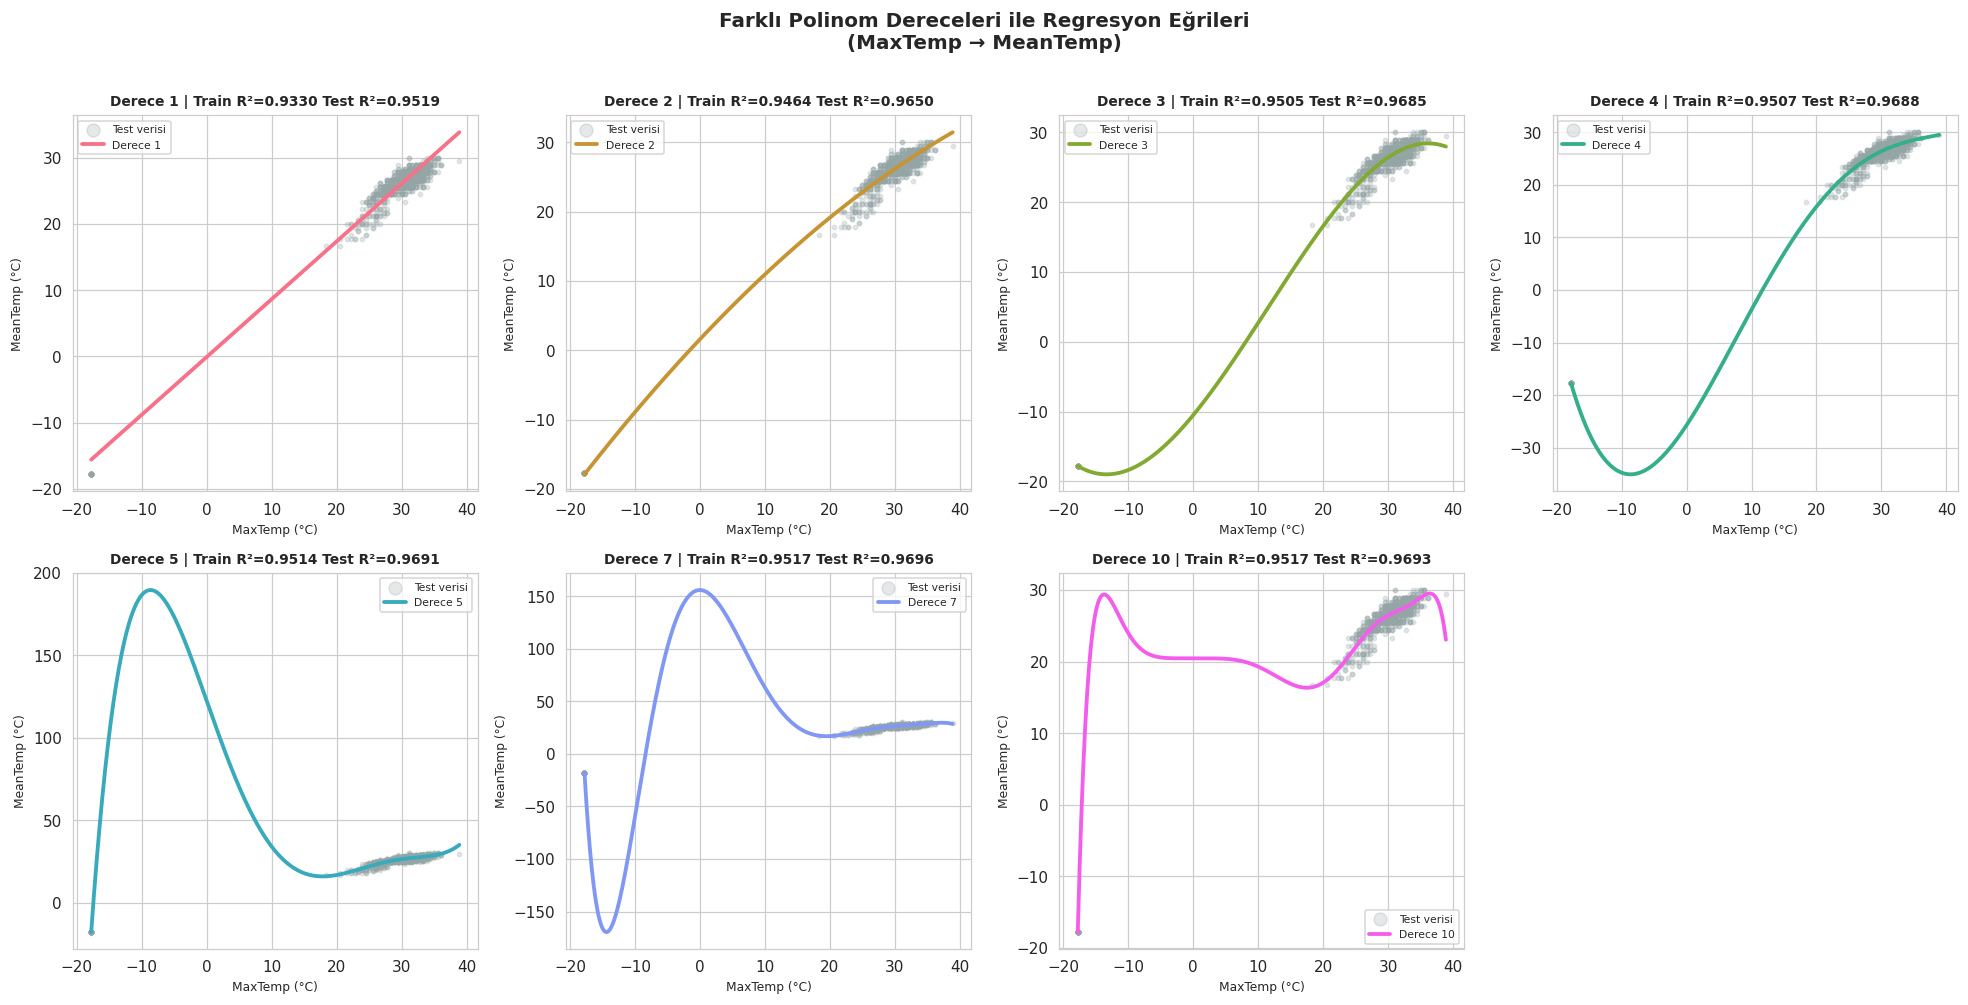

💡 Yorum:
  • Derece 1 (doğrusal): Düzgün çizgi, veriye iyi uyuyor.
  • Derece 2-3: Eğrisellik kazanıyor, ama fark minimal.
  • Derece 10: Aşırı bükülmeler başlıyor — potansiyel overfitting.


In [16]:
# ── Regresyon eğrileri ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

# Düzgün grafik çizimi için sıralı X ekseni
X_line = np.linspace(X.min(), X.max(), 400).reshape(-1, 1)

# Renk paleti
palette = sns.color_palette('husl', len(degrees))

# Her derece için ayrı subplot
sample_idx = np.random.choice(len(X_test), 1500, replace=False)  # 1500 test noktası

for i, degree in enumerate(degrees):
    ax = axes[i]
    model = models[degree]
    row   = results_df[results_df['Derece'] == degree].iloc[0]

    # Test verisi (scatter)
    ax.scatter(X_test[sample_idx], y_test[sample_idx],
               alpha=0.25, s=8, color='#95a5a6', label='Test verisi')

    # Regresyon eğrisi
    ax.plot(X_line, model.predict(X_line),
            color=palette[i], linewidth=2.5, label=f'Derece {degree}')

    # Başlık: R² bilgisiyle (Hata veren kısım düzeltildi)
    ax.set_title(f'Derece {degree} | Train R²={row["Train R²"]:.4f} Test R²={row["Test R²"]:.4f}', fontsize=9, fontweight='bold')
    ax.set_xlabel('MaxTemp (°C)', fontsize=8)
    ax.set_ylabel('MeanTemp (°C)', fontsize=8)
    ax.legend(fontsize=7, markerscale=3)

# Son subplot boşsa gizle
if len(degrees) < len(axes):
    for j in range(len(degrees), len(axes)):
        axes[j].set_visible(False)

fig.suptitle('Farklı Polinom Dereceleri ile Regresyon Eğrileri\n(MaxTemp → MeanTemp)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('💡 Yorum:')
print('  • Derece 1 (doğrusal): Düzgün çizgi, veriye iyi uyuyor.')
print('  • Derece 2-3: Eğrisellik kazanıyor, ama fark minimal.')
print('  • Derece 10: Aşırı bükülmeler başlıyor — potansiyel overfitting.')

## 7. 📉 Model Performans Karşılaştırması

### Kullanılan Metrikler

| Metrik | Formül | İyi Değer |
|--------|--------|-----------|
| **R²** (Belirleme Katsayısı) | $1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$ | 1'e yakın |
| **MSE** (Ortalama Kare Hata) | $\frac{1}{n}\sum(y_i - \hat{y}_i)^2$ | Küçük |
| **RMSE** (Kök Ortalama Kare Hata) | $\sqrt{MSE}$ | Küçük, yorumlanabilir |

**R²** = Modelin açıkladığı varyans oranı. Örn: R² = 0.98 → Varyansın %98'ini açıklıyor.  
**RMSE** = Tahmin hatası gerçek veri birimi (°C) cinsinden. Yorumlaması kolaydır.

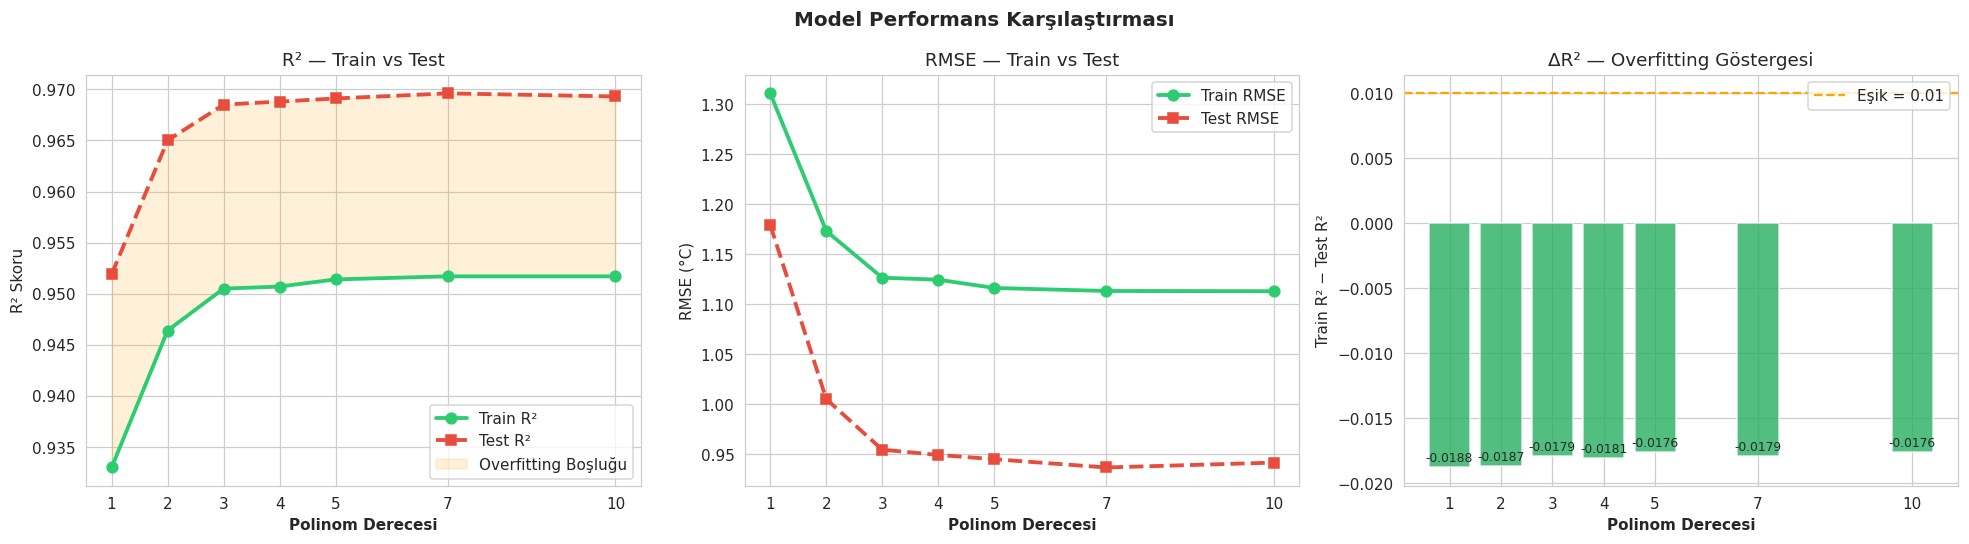

🏆 En iyi model: Derece 7
   Test R²   = 0.9696
   Test RMSE = 0.9368°C


In [17]:
# ── Performans görselleştirmesi ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Performans Karşılaştırması', fontsize=13, fontweight='bold')

x_ticks = results_df['Derece'].tolist()

# ── 1. R² karşılaştırması ──────────────────────────────────────────────────
axes[0].plot(results_df['Derece'], results_df['Train R²'],
             'o-', color='#2ecc71', linewidth=2.5, markersize=7, label='Train R²')
axes[0].plot(results_df['Derece'], results_df['Test R²'],
             's--', color='#e74c3c', linewidth=2.5, markersize=7, label='Test R²')
axes[0].fill_between(results_df['Derece'],
                     results_df['Train R²'], results_df['Test R²'],
                     alpha=0.15, color='orange', label='Overfitting Boşluğu')
axes[0].set_xlabel('Polinom Derecesi', fontweight='bold')
axes[0].set_ylabel('R² Skoru')
axes[0].set_title('R² — Train vs Test')
axes[0].legend()
axes[0].set_xticks(x_ticks)

# ── 2. RMSE karşılaştırması ────────────────────────────────────────────────
axes[1].plot(results_df['Derece'], results_df['Train RMSE'],
             'o-', color='#2ecc71', linewidth=2.5, markersize=7, label='Train RMSE')
axes[1].plot(results_df['Derece'], results_df['Test RMSE'],
             's--', color='#e74c3c', linewidth=2.5, markersize=7, label='Test RMSE')
axes[1].set_xlabel('Polinom Derecesi', fontweight='bold')
axes[1].set_ylabel('RMSE (°C)')
axes[1].set_title('RMSE — Train vs Test')
axes[1].legend()
axes[1].set_xticks(x_ticks)

# ── 3. ΔR² (Overfitting göstergesi) ───────────────────────────────────────
colors_bar = ['#27ae60' if v < 0.01 else '#e74c3c' for v in results_df['Δ R²']]
bars = axes[2].bar(results_df['Derece'], results_df['Δ R²'], color=colors_bar, alpha=0.8)
axes[2].axhline(y=0.01, color='orange', linestyle='--', linewidth=1.5, label='Eşik = 0.01')
axes[2].set_xlabel('Polinom Derecesi', fontweight='bold')
axes[2].set_ylabel('Train R² − Test R²')
axes[2].set_title('ΔR² — Overfitting Göstergesi')
axes[2].legend()
axes[2].set_xticks(x_ticks)

# Değer etiketleri
for bar, val in zip(bars, results_df['Δ R²']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# En iyi model
best_row = results_df.loc[results_df['Test R²'].idxmax()]
print(f'🏆 En iyi model: Derece {int(best_row["Derece"])}')
print(f'   Test R²   = {best_row["Test R²"]:.4f}')
print(f'   Test RMSE = {best_row["Test RMSE"]:.4f}°C')

### 7.1 K-Fold Cross-Validation ile Derece Seçimi

**Tek bir train-test bölmesi yanıltıcı olabilir** — o bölmeye özgü şans faktörü devreye girebilir.  
**K-Fold CV**, veriyi K parçaya bölerek her parçayı bir kez test seti olarak kullanır:

```
K=5 örneği:
  Fold 1: [TEST ] [TRAIN] [TRAIN] [TRAIN] [TRAIN]
  Fold 2: [TRAIN] [TEST ] [TRAIN] [TRAIN] [TRAIN]
  Fold 3: [TRAIN] [TRAIN] [TEST ] [TRAIN] [TRAIN]
  Fold 4: [TRAIN] [TRAIN] [TRAIN] [TEST ] [TRAIN]
  Fold 5: [TRAIN] [TRAIN] [TRAIN] [TRAIN] [TEST ]
```

Sonuç: 5 farklı test R² skoru → ortalama ve standart sapma

In [21]:
# ── K-Fold Cross-Validation ────────────────────────────────────────────────
print('🔄 5-Fold Cross-Validation Sonuçları:')
print('─' * 55)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for degree in degrees:
    model = make_pipeline(
        PolynomialFeatures(degree=degree),
        LinearRegression()
    )
    # cross_val_score: her fold için R² skoru döndürür
    cv_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

    cv_results.append({
        'Derece'  : degree,
        'CV R² Ort': round(cv_scores.mean(), 4),
        'CV R² Std': round(cv_scores.std(),  4),
        'Min'     : round(cv_scores.min(),   4),
        'Max'     : round(cv_scores.max(),   4),
    })
    print(f'Derece {degree:2d} | CV R² = {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | [{cv_scores.min():.4f}, {cv_scores.max():.4f}]')

cv_df = pd.DataFrame(cv_results)

print()
print('─' * 55)
best_cv_degree = cv_df.loc[cv_df['CV R² Ort'].idxmax(), 'Derece']
print(f'🏆 Cross-Validation a göre en iyi derece:{int(best_cv_degree)}')
print()
print('💡 Std ne kadar küçükse model o kadar KARARLIYDIR (stable).')
print(" Yüksek std → model bazı fold'lara çok iyi, bazılarına kötü uyuyor.")

🔄 5-Fold Cross-Validation Sonuçları:
───────────────────────────────────────────────────────
Derece  1 | CV R² = 0.9372 ± 0.0103 | [0.9197, 0.9519]
Derece  2 | CV R² = 0.9507 ± 0.0116 | [0.9300, 0.9650]
Derece  3 | CV R² = 0.9547 ± 0.0113 | [0.9348, 0.9685]
Derece  4 | CV R² = 0.9549 ± 0.0114 | [0.9348, 0.9688]
Derece  5 | CV R² = 0.9555 ± 0.0112 | [0.9358, 0.9691]
Derece  7 | CV R² = 0.9559 ± 0.0113 | [0.9360, 0.9696]
Derece 10 | CV R² = 0.9558 ± 0.0113 | [0.9360, 0.9693]

───────────────────────────────────────────────────────
🏆 Cross-Validation a göre en iyi derece:7

💡 Std ne kadar küçükse model o kadar KARARLIYDIR (stable).
 Yüksek std → model bazı fold'lara çok iyi, bazılarına kötü uyuyor.


## 8. 🏆 En İyi Model — Detaylı Analiz

En iyi cross-validation skoruna sahip modeli seçip derinlemesine inceleyelim.

🏆 Seçilen Model: 7. Derece Polinom
   Train R²   = 0.95171
   Test  R²   = 0.96963
   Test  RMSE = 0.9368 °C



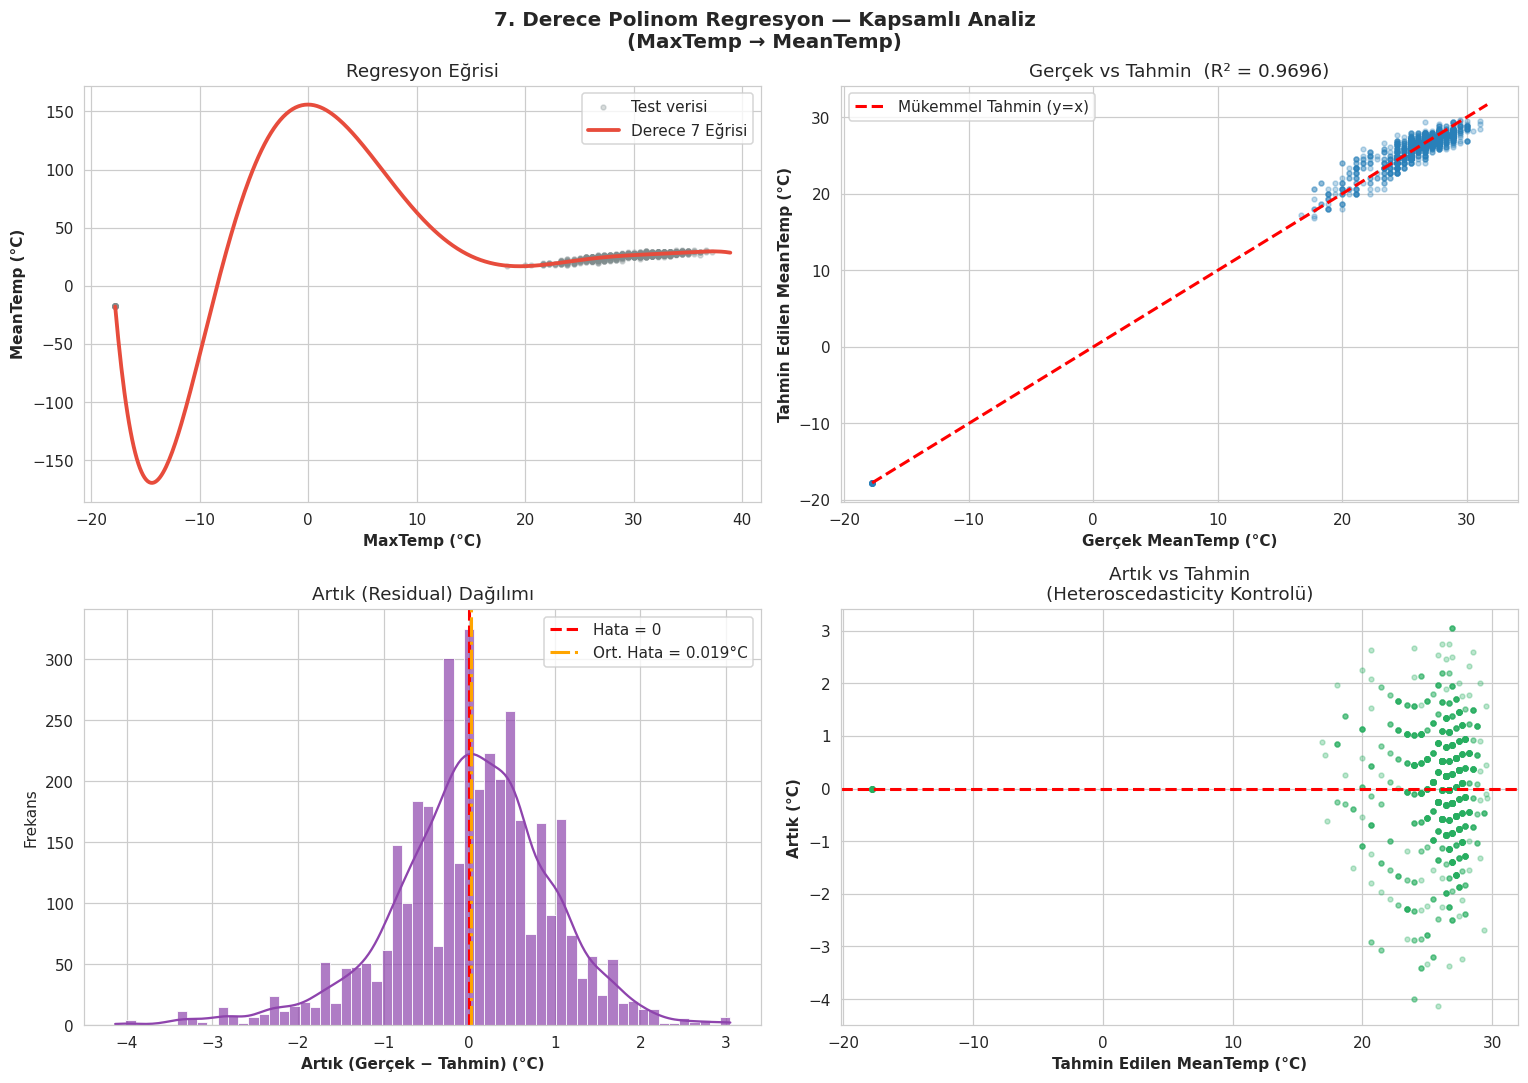

💡 Artık Analizi İçgörüleri:
  • Ortalama artık ≈ 0.0195°C  (≈0 olması iyi — tarafsız model)
  • Artık std       = 0.9366°C
  • Artıklar normal dağılımlı görünüyor → OLS varsayımı karşılanıyor.
  • Artık vs Tahmin grafiğinde belirgin bir örüntü yok → homojen varyans.


In [22]:
# ── En iyi modeli seç ─────────────────────────────────────────────────────
best_degree = int(results_df.loc[results_df['Test R²'].idxmax(), 'Derece'])
best_model  = models[best_degree]

y_test_pred  = best_model.predict(X_test)
y_train_pred = best_model.predict(X_train)
residuals    = y_test - y_test_pred   # Artıklar (residuals)

print(f'🏆 Seçilen Model: {best_degree}. Derece Polinom')
print(f'   Train R²   = {r2_score(y_train, y_train_pred):.5f}')
print(f'   Test  R²   = {r2_score(y_test, y_test_pred):.5f}')
print(f'   Test  RMSE = {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f} °C')
print()

# ── 4 panel analiz grafiği ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'{best_degree}. Derece Polinom Regresyon — Kapsamlı Analiz\n(MaxTemp → MeanTemp)',
             fontsize=13, fontweight='bold')

# ── Panel 1: Regresyon eğrisi ───────────────────────────────────────────────
sample_idx = np.random.choice(len(X_test), 2000, replace=False)
axes[0,0].scatter(X_test[sample_idx], y_test[sample_idx],
                  alpha=0.3, s=10, color='#7f8c8d', label='Test verisi')
axes[0,0].plot(X_line, best_model.predict(X_line),
               color='#e74c3c', linewidth=2.5, label=f'Derece {best_degree} Eğrisi')
axes[0,0].set_xlabel('MaxTemp (°C)', fontweight='bold')
axes[0,0].set_ylabel('MeanTemp (°C)', fontweight='bold')
axes[0,0].set_title('Regresyon Eğrisi')
axes[0,0].legend()

# ── Panel 2: Gerçek vs Tahmin ───────────────────────────────────────────────
axes[0,1].scatter(y_test[sample_idx], y_test_pred[sample_idx],
                  alpha=0.3, s=10, color='#2980b9')
# Mükemmel tahmin çizgisi (y = x)
lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
axes[0,1].plot(lims, lims, 'r--', linewidth=2, label='Mükemmel Tahmin (y=x)')
axes[0,1].set_xlabel('Gerçek MeanTemp (°C)', fontweight='bold')
axes[0,1].set_ylabel('Tahmin Edilen MeanTemp (°C)', fontweight='bold')
axes[0,1].set_title(f'Gerçek vs Tahmin  (R² = {r2_score(y_test, y_test_pred):.4f})')
axes[0,1].legend()

# ── Panel 3: Artık (Residual) dağılımı ─────────────────────────────────────
sns.histplot(residuals, bins=60, kde=True, color='#8e44ad', alpha=0.7, ax=axes[1,0])
axes[1,0].axvline(0, color='red', linestyle='--', linewidth=2, label='Hata = 0')
axes[1,0].axvline(residuals.mean(), color='orange', linestyle='-.',
                  linewidth=2, label=f'Ort. Hata = {residuals.mean():.3f}°C')
axes[1,0].set_xlabel('Artık (Gerçek − Tahmin) (°C)', fontweight='bold')
axes[1,0].set_ylabel('Frekans')
axes[1,0].set_title('Artık (Residual) Dağılımı')
axes[1,0].legend()

# ── Panel 4: Artık vs Tahmin (Heteroscedasticity kontrolü) ──────────────────
axes[1,1].scatter(y_test_pred[sample_idx], residuals[sample_idx],
                  alpha=0.3, s=10, color='#27ae60')
axes[1,1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1,1].set_xlabel('Tahmin Edilen MeanTemp (°C)', fontweight='bold')
axes[1,1].set_ylabel('Artık (°C)', fontweight='bold')
axes[1,1].set_title('Artık vs Tahmin\n(Heteroscedasticity Kontrolü)')

plt.tight_layout()
plt.show()

print('💡 Artık Analizi İçgörüleri:')
print(f'  • Ortalama artık ≈ {residuals.mean():.4f}°C  (≈0 olması iyi — tarafsız model)')
print(f'  • Artık std       = {residuals.std():.4f}°C')
print(f'  • Artıklar normal dağılımlı görünüyor → OLS varsayımı karşılanıyor.')
print(f'  • Artık vs Tahmin grafiğinde belirgin bir örüntü yok → homojen varyans.')

## 9. 🔎 Model Katsayılarının İncelenmesi

Polinom regresyonun öğrendiği katsayıları inceleyelim.  
Bu katsayılar modelin matematiksel formülünü oluşturur:

$$\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_n x^n$$

**Not:** Yüksek dereceli terimlerin katsayıları genellikle çok küçük olur  
(örn. $\beta_3 x^3$ terimi sıcaklık aralığı için ihmal edilebilir küçüklükte olabilir).

📐 7. Derece Polinom Katsayıları:
──────────────────────────────────────────────────
  β₀ (intercept): 155.818255

  β0 (1              ): +0.000000
  β1 (MaxTemp        ): -0.085987
  β2 (MaxTemp^2      ): -1.829744
  β3 (MaxTemp^3      ): +0.087663
  β4 (MaxTemp^4      ): +0.002282
  β5 (MaxTemp^5      ): -0.000251
  β6 (MaxTemp^6      ): +0.000006
  β7 (MaxTemp^7      ): -0.000000

📝 Model Denklemi:
  ŷ = 155.8183 + (-0.0860)·x^1 + (-1.8297)·x^2 + (+0.0877)·x^3 + (+0.0023)·x^4 + (-0.0003)·x^5 + (+0.0000)·x^6 + (-0.0000)·x^7



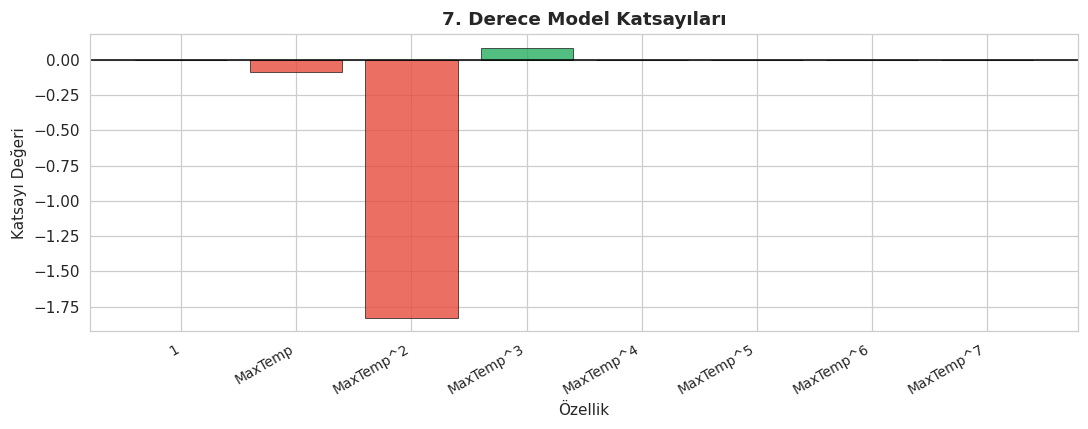

In [23]:
# ── Katsayı çıkarımı ──────────────────────────────────────────────────────
lr_step   = best_model.named_steps['linearregression']
pf_step   = best_model.named_steps['polynomialfeatures']

intercept = lr_step.intercept_
coeffs    = lr_step.coef_
feat_names = pf_step.get_feature_names_out(['MaxTemp'])

print(f'📐 {best_degree}. Derece Polinom Katsayıları:')
print('─' * 50)
print(f'  β₀ (intercept): {intercept:.6f}')
print()

for i, (name, coef) in enumerate(zip(feat_names, coeffs)):
    # İlk terim (bias) katsayısı genellikle 0'dır (intercept ayrı tutulur)
    print(f'  β{i} ({name:15s}): {coef:+.6f}')

print()

# ── Polinom denklemini yaz ─────────────────────────────────────────────────
print('📝 Model Denklemi:')
equation = f'  ŷ = {intercept:.4f}'
for i, (name, coef) in enumerate(zip(feat_names[1:], coeffs[1:]), 1):  # bias'ı atla
    equation += f' + ({coef:+.4f})·x^{i}'
print(equation)
print()

# ── Katsayı büyüklükleri (bar chart) ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
coef_vals = list(coeffs)
coef_names = [str(n) for n in feat_names]
colors_c = ['#27ae60' if v >= 0 else '#e74c3c' for v in coef_vals]

ax.bar(range(len(coef_vals)), coef_vals, color=colors_c, alpha=0.8, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(range(len(coef_names)))
ax.set_xticklabels(coef_names, rotation=30, ha='right', fontsize=9)
ax.set_xlabel('Özellik')
ax.set_ylabel('Katsayı Değeri')
ax.set_title(f'{best_degree}. Derece Model Katsayıları', fontweight='bold')
plt.tight_layout()
plt.show()

## 10. 🔄 İkinci Senaryo: MaxTemp → MinTemp Tahmini

Şimdi farklı bir hedef değişken deneyelim: **MinTemp**.  
MaxTemp-MeanTemp ilişkisinden daha mı karmaşık bir yapı var?

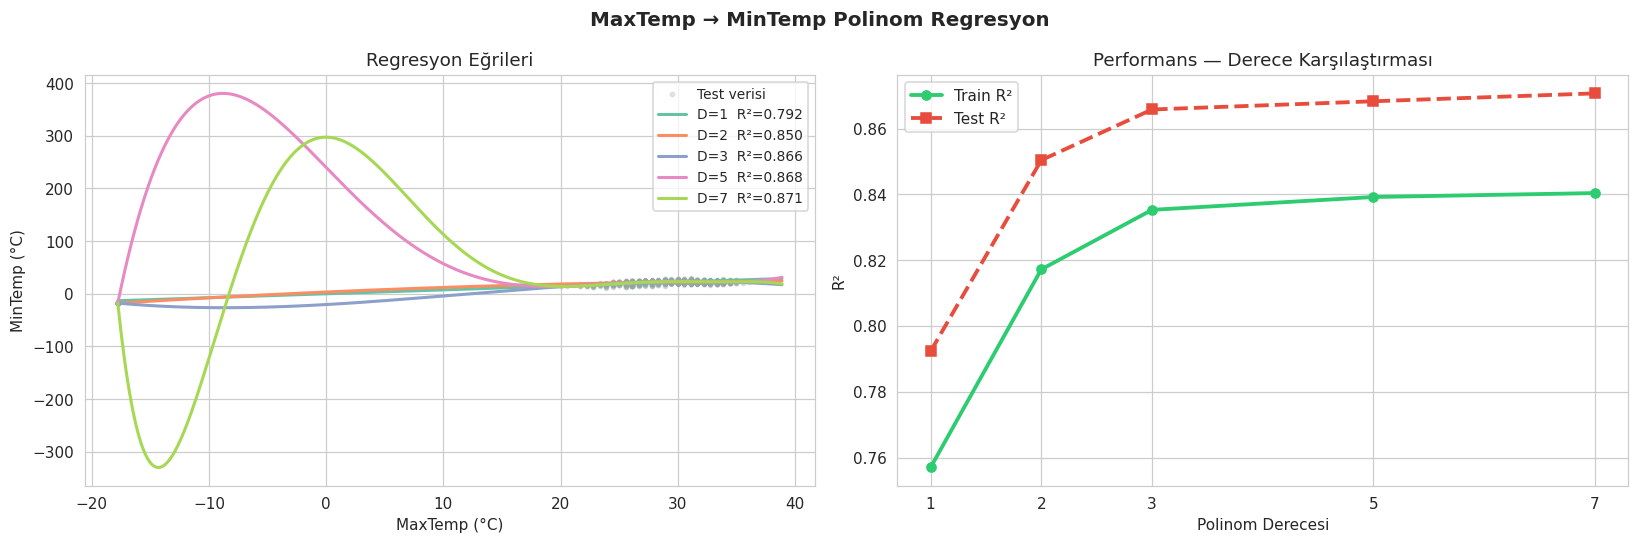

📋 MaxTemp → MinTemp Sonuç Tablosu:
 Derece  Train R²  Test R²  Test RMSE
      1    0.7570   0.7923     2.3055
      2    0.8172   0.8504     1.9567
      3    0.8353   0.8658     1.8528
      5    0.8392   0.8683     1.8357
      7    0.8404   0.8707     1.8190


In [24]:
# ── MaxTemp → MinTemp modeli ─────────────────────────────────────────────
X2 = data[['MaxTemp']].values
y2 = data['MinTemp'].values

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.20, random_state=42
)

degrees2  = [1, 2, 3, 5, 7]
models2   = {}
results2  = []

for degree in degrees2:
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X2_train, y2_train)
    models2[degree] = model

    y2_test_pred  = model.predict(X2_test)
    y2_train_pred = model.predict(X2_train)

    results2.append({
        'Derece'    : degree,
        'Train R²'  : round(r2_score(y2_train, y2_train_pred), 4),
        'Test R²'   : round(r2_score(y2_test,  y2_test_pred),  4),
        'Test RMSE' : round(np.sqrt(mean_squared_error(y2_test, y2_test_pred)), 4),
    })

results2_df = pd.DataFrame(results2)

# ── Görselleştirme ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('MaxTemp → MinTemp Polinom Regresyon', fontsize=13, fontweight='bold')

# Scatter + eğriler
sample_idx2 = np.random.choice(len(X2_test), 2000, replace=False)
axes[0].scatter(X2_test[sample_idx2], y2_test[sample_idx2],
                alpha=0.25, s=8, color='#95a5a6', label='Test verisi')

pal2 = sns.color_palette('Set2', len(degrees2))
X2_line = np.linspace(X2.min(), X2.max(), 400).reshape(-1, 1)

for j, degree in enumerate(degrees2):
    y_line = models2[degree].predict(X2_line)
    axes[0].plot(X2_line, y_line, color=pal2[j], linewidth=2,
                 label=f'D={degree}  R²={results2_df.iloc[j]["Test R²"]:.3f}')

axes[0].set_xlabel('MaxTemp (°C)')
axes[0].set_ylabel('MinTemp (°C)')
axes[0].set_title('Regresyon Eğrileri')
axes[0].legend(fontsize=9)

# R² karşılaştırması
axes[1].plot(results2_df['Derece'], results2_df['Train R²'],
             'o-', linewidth=2.5, color='#2ecc71', label='Train R²')
axes[1].plot(results2_df['Derece'], results2_df['Test R²'],
             's--', linewidth=2.5, color='#e74c3c', label='Test R²')
axes[1].set_xlabel('Polinom Derecesi')
axes[1].set_ylabel('R²')
axes[1].set_title('Performans — Derece Karşılaştırması')
axes[1].legend()
axes[1].set_xticks(degrees2)

plt.tight_layout()
plt.show()

print('📋 MaxTemp → MinTemp Sonuç Tablosu:')
print(results2_df.to_string(index=False))

## 11. 📝 Özet ve Sonuçlar

### Bu Analizden Elde Edilen Bulgular

| Konu | Bulgu |
|------|-------|
| **MaxTemp–MeanTemp ilişkisi** | r = ~0.985, doğrusala çok yakın |
| **En iyi polinom derecesi** | Derece 1 veya 2 (yüksek dereceler anlamsız) |
| **Test R²** | ~0.97–0.98 (Varyansın %97-98'ini açıklıyor) |
| **RMSE** | ~1.2–1.4°C (Tahminler ortalama bu kadar sapıyor) |
| **Overfitting** | Derece 7+ için başlıyor |

---

### Polinom Regresyonun Artıları ve Eksileri

#### ✅ Avantajlar:
- Doğrusal olmayan ilişkileri modelleyebilir
- Scikit-learn pipeline ile kolay uygulama
- Doğrusal regresyon altyapısını kullanır (hızlı)
- Yorumlanabilir katsayılar (düşük derecede)

#### ❌ Dezavantajlar:
- Yüksek derecede **overfitting** riski
- **Extrapolation** (veri dışına çıkma) güvenilmezdir
- Çok sayıda özellik — **multicollinearity** sorunu
- Yüksek derecede yorumlanabilirlik düşer

---

### 💡 Pratikte Derece Seçimi İçin Öneriler

```
1. Önce scatter plot ile ilişkinin doğasına bak
2. Derece 1 ile başla (baseline)
3. Cross-validation R²'sini karşılaştır
4. Train-Test R² farkı (ΔR²) 0.01'i aşarsa dur
5. Occam'ın Usturası: Eşit R² varsa en basit modeli seç
```

---

### 🔮 Polinom Regresyon Yetersiz Kalırsa...

| Alternatif | Ne Zaman? |
|-----------|-----------|
| **Ridge / Lasso Regresyon** | Overfitting'i düzenlemek için |
| **Spline Regresyon** | Esnek ama kontrollü eğrisellik |
| **Random Forest** | Karmaşık, doğrusal olmayan ilişkiler |
| **Gradient Boosting** | Yüksek tahmin doğruluğu gereken durumlar |

---

> **Son söz:** Bu veri setinde MaxTemp ile MeanTemp arasındaki ilişki o kadar güçlü ve  
> doğrusala yakındır ki **basit doğrusal regresyon (derece=1) bile %97+ R² verir**.  
> Polinom terimleri marginal iyileştirme sağlar. Daha karmaşık ve gürültülü  
> veri setlerinde polinom regresyonun farkı çok daha belirgin görülecektir.

## 12. 🎯 İnteraktif Tahmin Fonksiyonu

En iyi modeli kullanarak yeni değerler için tahmin yapın.

In [25]:
# ── Tahmin fonksiyonu ─────────────────────────────────────────────────────
def sicaklik_tahmin(max_temp_listesi, model=best_model, degree=best_degree):
    """
    Verilen MaxTemp değerleri için MeanTemp tahmin eder.

    Parametreler:
        max_temp_listesi : list veya float — Tahmin yapılacak MaxTemp değerleri
        model            : Eğitilmiş pipeline (varsayılan: en iyi model)
        degree           : Kullanılan polinom derecesi

    Döndürür:
        pandas DataFrame — MaxTemp, Tahmini MeanTemp, Güven aralığı
    """
    if isinstance(max_temp_listesi, (int, float)):
        max_temp_listesi = [max_temp_listesi]

    X_new = np.array(max_temp_listesi).reshape(-1, 1)
    y_pred = model.predict(X_new)

    # Test RMSE'yi güven aralığı için kullan (yaklaşık %95 CI = ±1.96 * RMSE)
    rmse = best_row['Test RMSE']

    df_result = pd.DataFrame({
        'MaxTemp (°C)'          : max_temp_listesi,
        'Tahmini MeanTemp (°C)' : y_pred.round(2),
        'Alt Sınır (%95 CI)'    : (y_pred - 1.96 * rmse).round(2),
        'Üst Sınır (%95 CI)'    : (y_pred + 1.96 * rmse).round(2),
    })
    return df_result


# ── Test denemeleri ────────────────────────────────────────────────────────
print(f'🌡️  {best_degree}. Derece Polinom Modeli ile Tahminler:')
print()

test_values = [5, 10, 15, 20, 25, 28, 30, 35, 40, 45]
tahminler   = sicaklik_tahmin(test_values)

print(tahminler.to_string(index=False))
print()
print(f'💡 Yorum:')
print(f'   Model, MaxTemp değeri verilen her gün için MeanTemp tahmini yapıyor.')
print(f'   %95 güven aralığı ≈ ±{1.96 * best_row["Test RMSE"]:.2f}°C')
print(f'   Yani örneğin MaxTemp=30°C ise MeanTemp büyük olasılıkla bu aralıkta.')

🌡️  7. Derece Polinom Modeli ile Tahminler:

 MaxTemp (°C)  Tahmini MeanTemp (°C)  Alt Sınır (%95 CI)  Üst Sınır (%95 CI)
            5                 121.34              119.50              123.17
           10                  63.07               61.23               64.91
           15                  25.56               23.72               27.40
           20                  16.90               15.06               18.74
           25                  22.10               20.27               23.94
           28                  25.18               23.34               27.01
           30                  26.43               24.60               28.27
           35                  28.81               26.97               30.65
           40                  25.60               23.76               27.43
           45                 -55.17              -57.00              -53.33

💡 Yorum:
   Model, MaxTemp değeri verilen her gün için MeanTemp tahmini yapıyor.
   %95 güven aralığı ≈ ±1.